In [4]:
# ===================== IMPORT LIBRARIES =====================
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Advanced boosting model
from xgboost import XGBRegressor

In [1]:
# ===================== CLASS DEFINITION =====================
class SaffronMLModel:
    
    def __init__(self, file_path):
        # Store dataset path
        self.file_path = file_path
        
        # Initialize variables
        self.df = None     # Full dataset
        self.X = None      # Features
        self.y = None      # Target
        self.model = None  # Best model selected

    
    # ===================== LOAD DATA =====================
    def load_data(self):
        # Read CSV file
        self.df = pd.read_csv(self.file_path)
        
        print("\n📥 Data Preview:")
        print(self.df.sample(5))   # Show first 5 rows


    # ===================== PREPROCESSING =====================
    def preprocess(self):
        # Fill missing values with column mean
        self.df = self.df.fillna(self.df.mean())
        
        # Separate features (X) and target (y)
        self.X = self.df.drop("Growth", axis=1)
        self.y = self.df["Growth"]
        
        print("✅ Preprocessing done")


    # ===================== TRAIN-TEST SPLIT =====================
    def split_data(self, test_size=0.2):
        # Split dataset into training and testing sets
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=42
        )
        
        print("✅ Data split completed")


    # ===================== MODEL COMPARISON =====================
    def compare_models(self):
        print("\n🤖 Comparing Models...")

        # Define models
        self.models = {
            "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
            "Gradient Boosting": GradientBoostingRegressor(random_state=42),
            "XGBoost": XGBRegressor(random_state=42, eval_metric='rmse')
        }

        self.results = {}      # Store R2 scores
        self.predictions = {}  # Store predictions

        # Train and evaluate each model
        for name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            y_pred = model.predict(self.X_test)
            
            r2 = r2_score(self.y_test, y_pred)
            
            self.results[name] = r2
            self.predictions[name] = y_pred
            
            print(f"{name} R2 Score: {round(r2, 4)}")

        # Select best model based on highest R2
        best_model_name = max(self.results, key=self.results.get)
        print("\n🏆 Best Model:", best_model_name)

        self.model = self.models[best_model_name]


    # ===================== TRAIN BEST MODEL =====================
    def train(self):
        # Train the best selected model again
        self.model.fit(self.X_train, self.y_train)
        print("✅ Best model trained")


    # ===================== MODEL EVALUATION =====================
    def evaluate(self):
        # Predict on test data
        self.y_pred = self.model.predict(self.X_test)
        
        # Calculate metrics
        mse = mean_squared_error(self.y_test, self.y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(self.y_test, self.y_pred)
        r2 = r2_score(self.y_test, self.y_pred)
        
        train_r2 = self.model.score(self.X_train, self.y_train)
        test_r2  = self.model.score(self.X_test, self.y_test)
        
        print("\n📊 Model Evaluation:")
        print("Train R2:", round(train_r2, 4))
        print("Test  R2:", round(test_r2, 4))
        print("MSE :", round(mse, 4))
        print("RMSE:", round(rmse, 4))
        print("MAE :", round(mae, 4))
        print("R2  :", round(r2, 4))
        
        # Overfitting / underfitting detection
        gap = abs(train_r2 - test_r2)

        if gap > 0.15:
            print("⚠️ Strong Overfitting")
        elif gap > 0.05:
            print("⚠️ Mild Overfitting")
        elif train_r2 < 0.5 and test_r2 < 0.5:
            print("⚠️ Underfitting")
        else:
            print("✅ Model looks balanced")
        
        return r2


    # ===================== CROSS VALIDATION =====================
    def cross_validate(self):
        # Perform 5-fold cross validation
        scores = cross_val_score(self.model, self.X, self.y, cv=5, scoring='r2')
        
        print("\n🔁 Cross Validation R2 Scores:", scores)
        print("Average R2:", round(scores.mean(), 4))


    # ===================== LINE PLOT =====================
    def compare_all_models_line(self):
        print("\n📊 Comparing All Models (Line Plot)...")

        plt.figure(figsize=(12, 6))

        # Reset index to align correctly
        y_test_sorted = self.y_test.reset_index(drop=True)

        # Plot actual values
        plt.plot(y_test_sorted[:50], label="Actual", marker='o')

        # Plot predictions of each model
        for name, y_pred in self.predictions.items():
            y_pred_series = pd.Series(y_pred).reset_index(drop=True)
            plt.plot(y_pred_series[:50], linestyle="dashed", label=name)

        plt.title("Actual vs Predictions (First 50 Samples)")
        plt.xlabel("Index")
        plt.ylabel("Growth")
        plt.legend()
        plt.grid(True)
        plt.show()


    # ===================== SCATTER PLOT =====================
    def plot_all_models(self):
        print("\n📊 Scatter Plot Comparison...")

        n_models = len(self.predictions)
        plt.figure(figsize=(5 * n_models, 5))

        for i, (name, y_pred) in enumerate(self.predictions.items(), 1):
            plt.subplot(1, n_models, i)
            
            plt.scatter(self.y_test, y_pred, alpha=0.7)

            # Ideal diagonal line
            min_val = min(self.y_test.min(), y_pred.min())
            max_val = max(self.y_test.max(), y_pred.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')

            plt.xlabel("Actual")
            plt.ylabel("Predicted")
            plt.title(f"{name}\nR2={round(self.results[name],3)}")
            plt.grid(True)

        plt.tight_layout()
        plt.show()


    # ===================== BEST MODEL LINE PLOT =====================
    def compare_predictions(self):
        print("📊 Best Model Comparison Plot")

        plt.figure(figsize=(10, 5))

        y_test_sorted = self.y_test.reset_index(drop=True)
        y_pred_sorted = pd.Series(self.y_pred).reset_index(drop=True)

        plt.plot(y_test_sorted[:50], label="Actual", marker='o')
        plt.plot(y_pred_sorted[:50], label="Predicted", linestyle="dashed")

        plt.title("Best Model: Actual vs Predicted")
        plt.xlabel("Index")
        plt.ylabel("Growth")
        plt.legend()
        plt.grid(True)
        plt.show()


    # ===================== MANUAL PREDICTION =====================
    def predict_manual(self):
        print("\n🔍 Enter Values for Prediction:")

        temp = float(input("Temperature: "))
        hum = float(input("Humidity: "))
        light = float(input("Light: "))
        soil = float(input("Soil Moisture: "))
        co2 = float(input("CO2: "))

        # Ensure correct column order
        data = pd.DataFrame([[temp, hum, light, soil, co2]], columns=self.X.columns)

        prediction = self.model.predict(data)

        print(f"\n🌱 Predicted Growth: {round(prediction[0], 4)}")

In [2]:
# ===================== MAIN EXECUTION =====================
phase1 = SaffronMLModel("../datasets/phase1_saffron.csv")
phase2 = SaffronMLModel("../datasets/phase2_saffron.csv")
phase3 = SaffronMLModel("../datasets/phase3_saffron.csv")
phase4 = SaffronMLModel("../datasets/phase4_saffron.csv")

phases = [phase1, phase2, phase3, phase4]



=================================== 🌱 PHASE 1 ============================

📥 Data Preview:
     Temperature  Humidity  Light  Soil_Moisture     CO2  Growth
356        25.04     45.21   0.92           0.75  445.23   91.63
60         25.82     48.55   0.87           0.34  401.79   84.05
156        26.27     46.45   0.17           0.57  406.77   73.22
13         25.41     49.38   0.04          -0.00  407.10   60.22
152        25.31     47.98   0.70           0.27  436.77   78.37
✅ Preprocessing done
✅ Data split completed

🤖 Comparing Models...
Random Forest R2 Score: 0.9703
Gradient Boosting R2 Score: 0.9781
XGBoost R2 Score: 0.9778

🏆 Best Model: Gradient Boosting

📊 Scatter Plot Comparison...


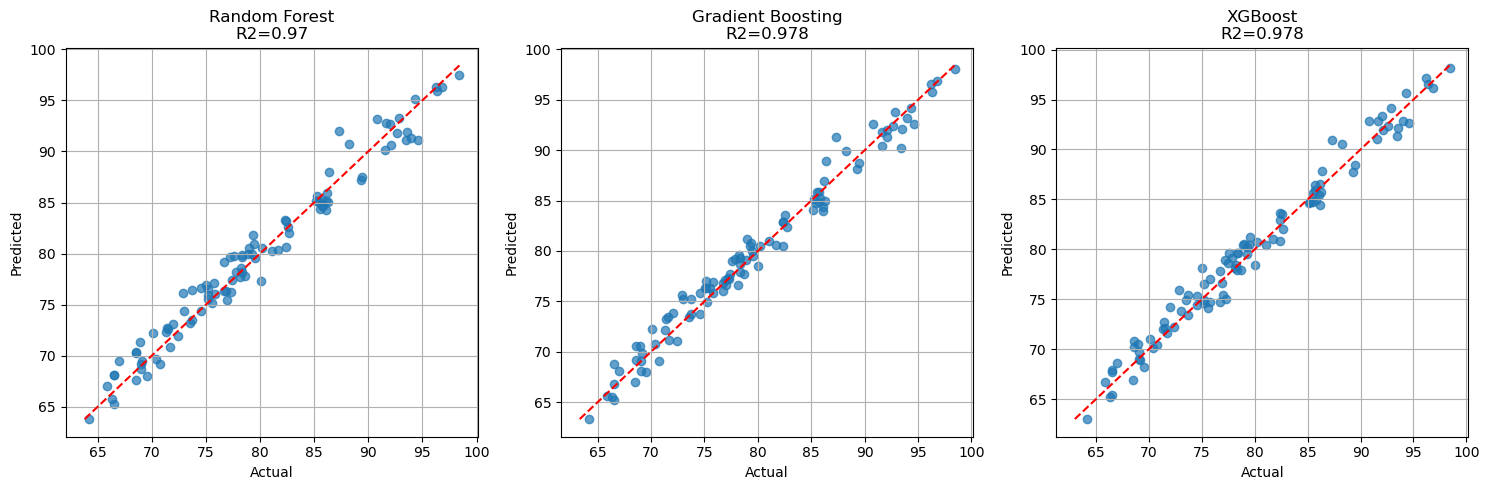


📊 Comparing All Models (Line Plot)...


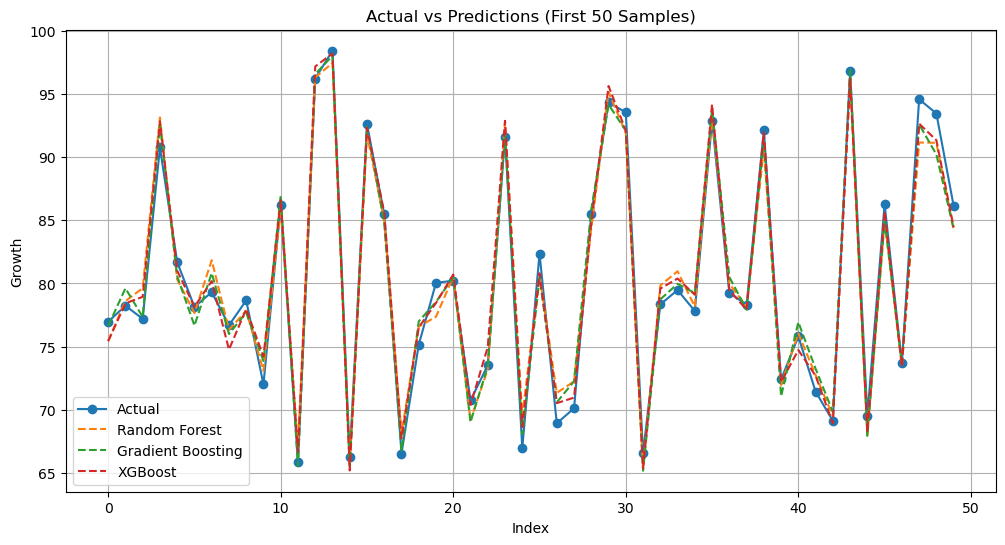

✅ Best model trained

📊 Model Evaluation:
Train R2: 0.9971
Test  R2: 0.9781
MSE : 1.6239
RMSE: 1.2743
MAE : 1.0125
R2  : 0.9781
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.98380975 0.98697519 0.98740265 0.98566579 0.97978337]
Average R2: 0.9847
📊 Best Model Comparison Plot


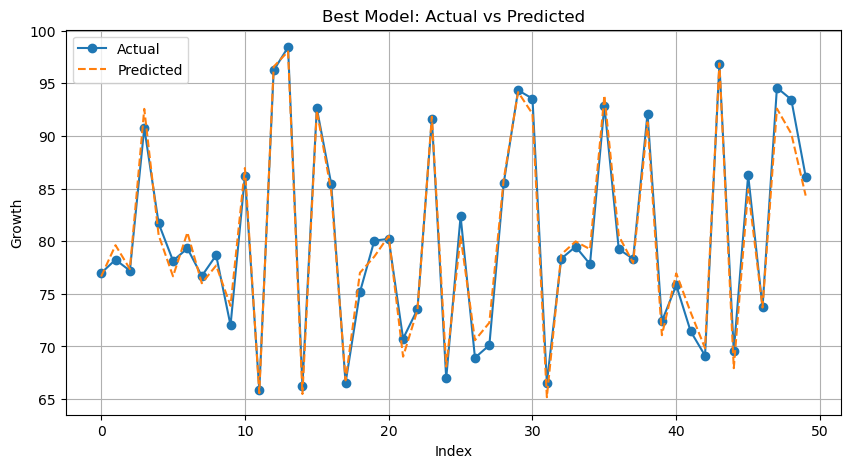


=================================== 🌱 PHASE 2 ============================

📥 Data Preview:
     Temperature  Humidity   Light  Soil_Moisture     CO2  Growth
390        16.47     57.82  385.49          10.35  519.13   82.41
407        14.15     59.31  282.65          10.24  558.19   70.16
97         15.26     55.20  331.26          12.08  509.96   76.52
189        14.94     54.83  233.33          11.10  525.55   68.44
418        13.36     54.55  210.40          10.82  579.28   61.65
✅ Preprocessing done
✅ Data split completed

🤖 Comparing Models...
Random Forest R2 Score: 0.9304
Gradient Boosting R2 Score: 0.9551
XGBoost R2 Score: 0.9098

🏆 Best Model: Gradient Boosting

📊 Scatter Plot Comparison...


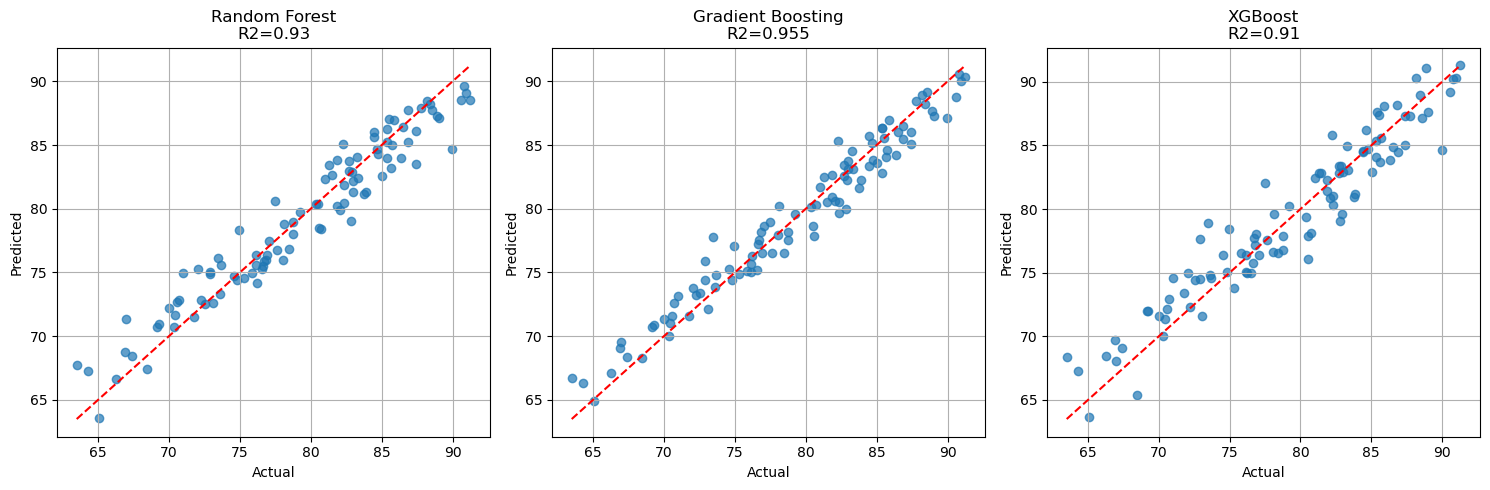


📊 Comparing All Models (Line Plot)...


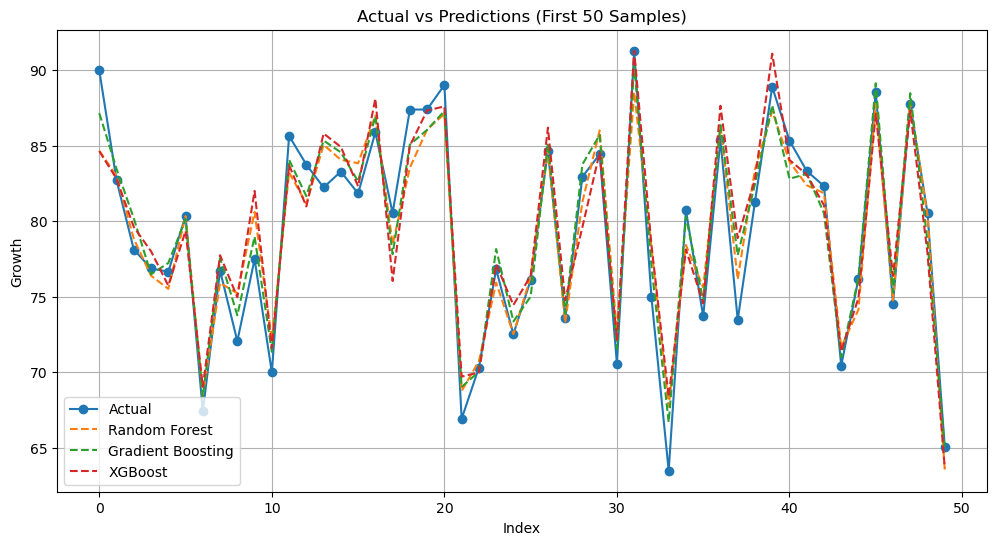

✅ Best model trained

📊 Model Evaluation:
Train R2: 0.9966
Test  R2: 0.9551
MSE : 2.159
RMSE: 1.4694
MAE : 1.2099
R2  : 0.9551
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.96405274 0.95582718 0.97733117 0.95593124 0.97015328]
Average R2: 0.9647
📊 Best Model Comparison Plot


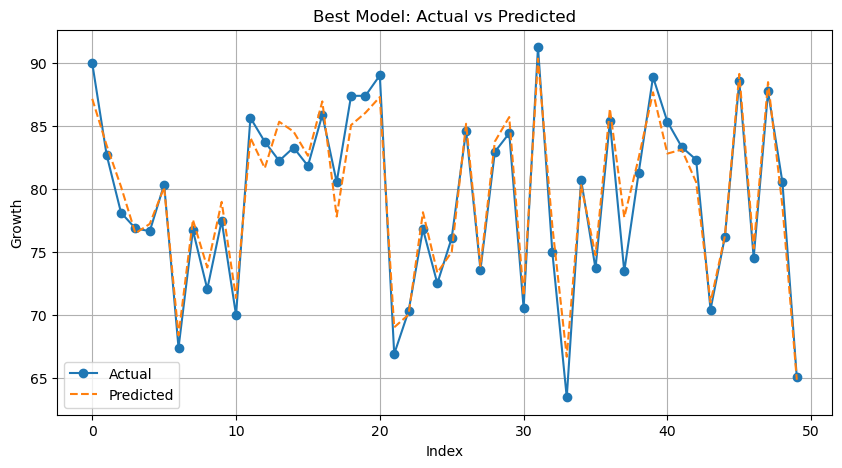


=================================== 🌱 PHASE 3 ============================

📥 Data Preview:
     Temperature  Humidity    Light  Soil_Moisture     CO2  Growth
174        16.62     62.26  1089.36          27.32  713.45   80.34
129        14.45     56.88  1114.23          25.58  767.09   69.45
32         15.36     57.23  1468.30          22.89  709.03   74.61
230        15.66     59.95  1907.70          21.40  796.22   86.43
327        16.57     59.92  1141.52          20.41  716.85   70.67
✅ Preprocessing done
✅ Data split completed

🤖 Comparing Models...
Random Forest R2 Score: 0.9553
Gradient Boosting R2 Score: 0.9747
XGBoost R2 Score: 0.9609

🏆 Best Model: Gradient Boosting

📊 Scatter Plot Comparison...


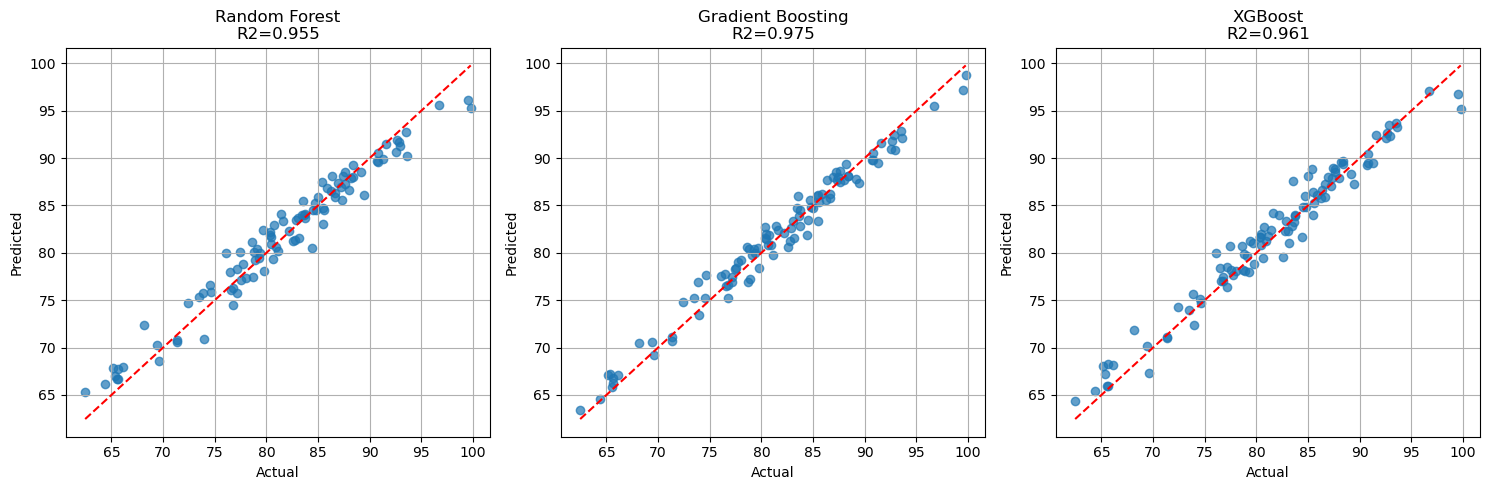


📊 Comparing All Models (Line Plot)...


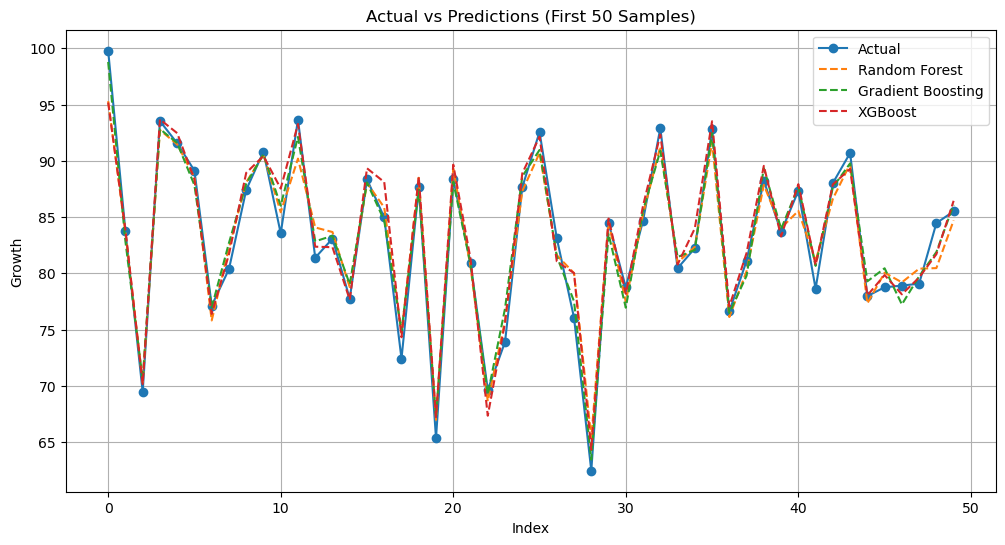

✅ Best model trained

📊 Model Evaluation:
Train R2: 0.9959
Test  R2: 0.9747
MSE : 1.6181
RMSE: 1.2721
MAE : 1.0553
R2  : 0.9747
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.97338568 0.9740276  0.96902227 0.97543993 0.96973995]
Average R2: 0.9723
📊 Best Model Comparison Plot


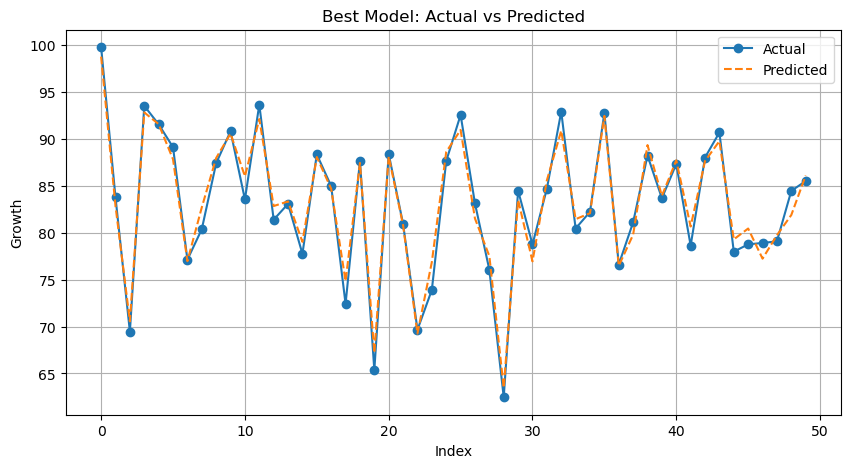


=================================== 🌱 PHASE 4 ============================

📥 Data Preview:
     Temperature  Humidity    Light  Soil_Moisture     CO2  Growth
173        18.93     59.98  9954.02          49.37  936.92   89.46
48         19.98     60.95  8305.42          42.95  831.18   79.65
168        19.58     69.72  5825.00          50.04  965.79   80.84
438        20.35     63.01  8134.50          41.73  918.64   80.99
414        18.59     66.36  7926.84          48.34  903.85   82.49
✅ Preprocessing done
✅ Data split completed

🤖 Comparing Models...
Random Forest R2 Score: 0.927
Gradient Boosting R2 Score: 0.9588
XGBoost R2 Score: 0.926

🏆 Best Model: Gradient Boosting

📊 Scatter Plot Comparison...


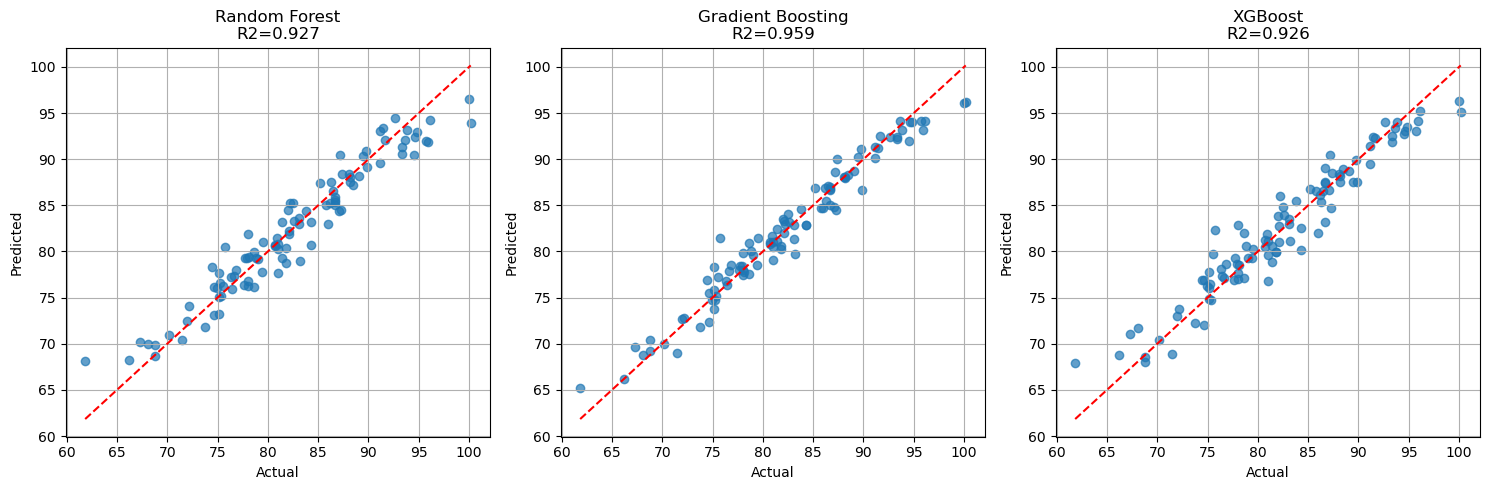


📊 Comparing All Models (Line Plot)...


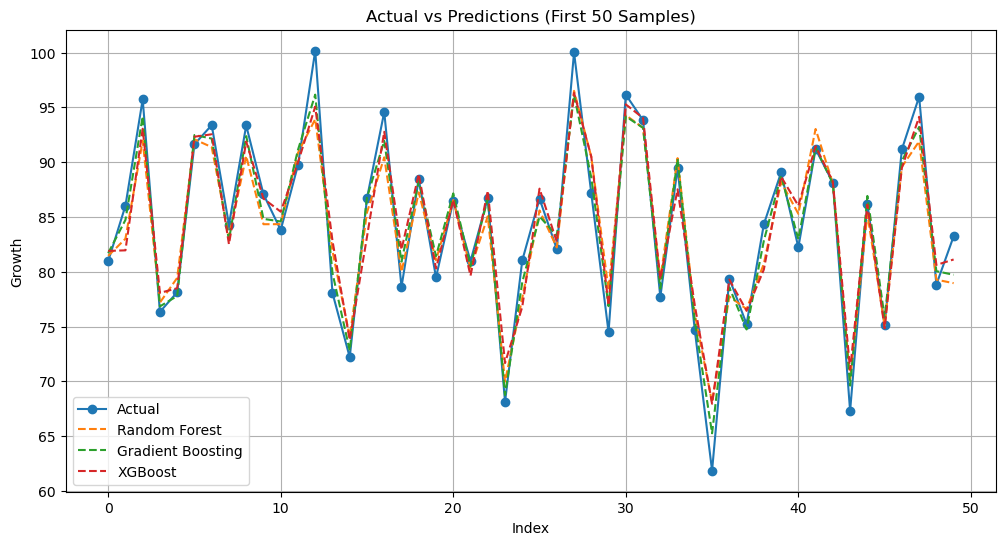

✅ Best model trained

📊 Model Evaluation:
Train R2: 0.9961
Test  R2: 0.9588
MSE : 2.5314
RMSE: 1.591
MAE : 1.1972
R2  : 0.9588
✅ Model looks balanced

🔁 Cross Validation R2 Scores: [0.96804574 0.97128938 0.96575815 0.9721137  0.96090752]
Average R2: 0.9676
📊 Best Model Comparison Plot


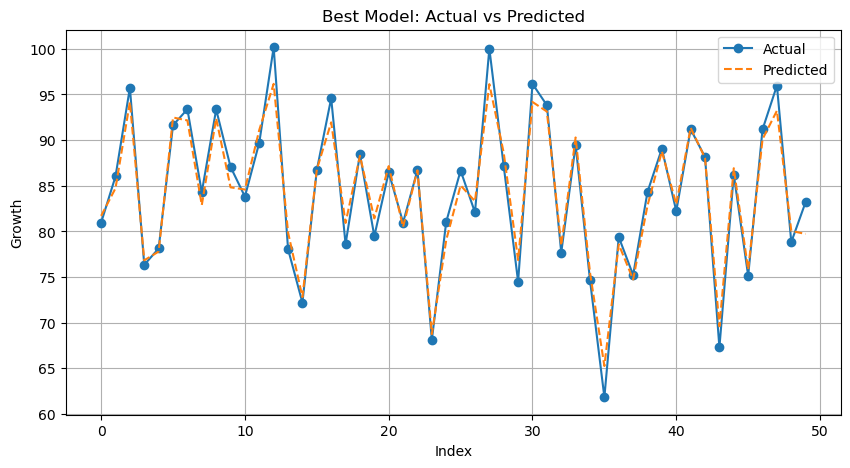


🏁 Final R2 Comparison Across Phases:
Phase 1 R2 Score: 0.9781
Phase 2 R2 Score: 0.9551
Phase 3 R2 Score: 0.9747
Phase 4 R2 Score: 0.9588


In [5]:
# ===================== OUTPUT / EXECUTION ============================

# Store R2 score of each phase for final comparison
results = []

# Loop through all 4 phases (datasets)
for i, phase in enumerate(phases, start=1):
    
    # Print phase header (for clarity in output)
    print(f"\n=================================== 🌱 PHASE {i} ============================")
    
    
    # ------------------ STEP 1: LOAD DATA ------------------
    # Reads CSV file and shows first few rows
    phase.load_data()
    
    
    # ------------------ STEP 2: PREPROCESS ------------------
    # Handles missing values and separates features (X) and target (y)
    phase.preprocess()
    
    
    # ------------------ STEP 3: TRAIN-TEST SPLIT ------------------
    # Splits data into training (80%) and testing (20%)
    phase.split_data()
    
    
    # ------------------ STEP 4: MODEL COMPARISON ------------------
    # Trains multiple models (RF, GB, XGB)
    # Stores predictions and selects best model based on R2 score
    phase.compare_models()
    
    
    # ------------------ STEP 5: VISUALIZATION (ALL MODELS) ------------------
    # Scatter plot:
    # Shows Actual vs Predicted values for each model
    # Helps visually check accuracy (points near diagonal = good model)
    phase.plot_all_models()
    
    
    # Line plot:
    # Compares first 50 predictions of all models vs actual values
    # Helps see prediction trends
    phase.compare_all_models_line()
    
    
    # ------------------ STEP 6: TRAIN BEST MODEL ------------------
    # Retrains only the best model selected earlier
    phase.train()
    
    
    # ------------------ STEP 7: MODEL EVALUATION ------------------
    # Calculates:
    # - R2 (accuracy)
    # - RMSE (error)
    # - MAE (average error)
    # Also detects overfitting / underfitting
    r2 = phase.evaluate()
    
    
    # ------------------ STEP 8: CROSS VALIDATION ------------------
    # Runs 5-fold validation to check model stability
    # Important: tells if model generalizes well
    phase.cross_validate()
    
    
    # ------------------ STEP 9: BEST MODEL VISUALIZATION ------------------
    # Line plot for best model only
    # Compares actual vs predicted clearly
    phase.compare_predictions()
    
    
    # ------------------ OPTIONAL STEP ------------------
    # Manual prediction (user input)
    # Uncomment if needed
    # phase.predict_manual()
    
    
    # Store R2 score of this phase
    results.append(r2)


# ===================== FINAL RESULT SUMMARY ============================

print("\n🏁 Final R2 Comparison Across Phases:")

# Print R2 score of each phase
for i, r2 in enumerate(results, start=1):
    print(f"Phase {i} R2 Score: {round(r2, 4)}")